# Adult Census Income – Exploratory Data Analysis (EDA)

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) trên dataset Adult Census Income theo đúng yêu cầu của bài toán, nhằm làm rõ đặc điểm dữ liệu và phục vụ cho các bước tiền xử lý tiếp theo.


## Mục tiêu

- Kiểm tra phân phối của các biến số
- Phân tích tương quan giữa các thuộc tính
- Phân tích và xác định cơ chế giá trị thiếu

## Nội dung thực hiện

### 1. Kiểm tra phân phối (Distribution Analysis)

- Thực hiện kiểm định:
  - **Shapiro–Wilk** (n ≤ 5000) hoặc  
  - **D’Agostino–Pearson** (n > 5000)
- Phân loại các biến số:
  - Phân phối chuẩn
  - Không chuẩn (skewed)
- Sử dụng kết quả để định hướng lựa chọn phương pháp chuẩn hóa phù hợp

### 2. Phân tích tương quan đa biến

- Xây dựng heatmap tương quan:
  - **Pearson correlation** (tuyến tính)
  - **Spearman correlation** (phi tuyến / thứ hạng)
- Xác định các cặp biến có tương quan cao (|r| > 0.9)
- Đánh giá nguy cơ **đa cộng tuyến (multicollinearity)** và đề xuất xử lý

### 3. Phân tích giá trị thiếu

- Trực quan hóa dữ liệu thiếu bằng **missingno**
- Kiểm định giả thuyết **MCAR** (Little’s MCAR test)
- Phân loại cơ chế thiếu:
  - MCAR
  - MAR
  - MNAR
- Giải thích và liên hệ với đặc điểm dữ liệu

## Ý nghĩa

Các kết quả từ EDA là cơ sở quan trọng để:
- Lựa chọn phương pháp imputation phù hợp
- Quyết định cách xử lý outlier và scaling
- Xây dựng pipeline tiền xử lý hợp lý trong notebook tiếp theo

# Import thư viện và cấu hình đường dẫn

In [8]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import normaltest, chi2_contingency

SEED = 42
np.random.seed(SEED)

CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
DATA_PATH = os.path.join(DATA_DIR, "raw", "adult.csv")

In [9]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Trong dataset, ký tự "?" được dùng để biểu diễn giá trị bị thiếu (missing values). Vì vậy, ta chuyển "?" thành NaN để pandas nhận diện và xử lý dữ liệu thiếu đúng cách.

In [10]:
df.replace("?", pd.NA, inplace=True)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,<NA>,77053,HS-grad,9,Widowed,<NA>,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,<NA>,186061,Some-college,10,Widowed,<NA>,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


### Ý nghĩa các thuộc tính

| Thuộc tính | Ý nghĩa |
|-----------|--------|
| age | Tuổi của cá nhân |
| workclass | Loại hình công việc (Private, Government, ...) |
| fnlwgt | Trọng số dân số (đại diện số người tương tự) |
| education | Trình độ học vấn |
| education.num | Số năm học tương ứng |
| marital.status | Tình trạng hôn nhân |
| occupation | Nghề nghiệp |
| relationship | Quan hệ trong gia đình |
| race | Chủng tộc |
| sex | Giới tính |
| capital.gain | Thu nhập từ đầu tư |
| capital.loss | Lỗ từ đầu tư |
| hours.per.week | Số giờ làm việc mỗi tuần |
| native.country | Quốc gia |
| income | Mức thu nhập (target) |

# 1. Khảo sát dữ liệu ban đầu
### Mục tiêu
Phân tích tổng quan dataset nhằm:
- Xác định kiểu dữ liệu
- Kiểm tra missing values và giá trị rỗng
- Phát hiện dữ liệu trùng lặp
- Quan sát phân phối biến mục tiêu

Các thông tin này là cơ sở để thiết kế pipeline tiền xử lý phù hợp.

In [11]:
target_col = "income"
assert target_col in df.columns, f"Không tìm thấy cột target '{target_col}'"

# Phân loại cột
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]

print("Các cột số:", numeric_cols)
print("Các cột phân loại:", categorical_cols)
print("Biến mục tiêu:", target_col)

# Missing
print("\nTỷ lệ giá trị thiếu (%):")
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio (%)": (df.isna().mean()*100).round(2)
}).sort_values("missing_ratio (%)", ascending=False)
display(missing_df)


# Empty values
empty_rows = df.isna().all(axis=1).sum()
empty_strings = (df.select_dtypes(include="object") == "").sum().sum()

print(f"\nSố dòng toàn NaN: {empty_rows}")
print(f"Số ô chuỗi rỗng: {empty_strings}")

# Duplicate
dup_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {dup_count}")

Các cột số: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Các cột phân loại: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Biến mục tiêu: income

Tỷ lệ giá trị thiếu (%):


,missing_count,missing_ratio (%)
occupation,1843,5.66
workclass,1836,5.64
native.country,583,1.79
age,0,0.00
fnlwgt,0,0.00
education,0,0.00
education.num,0,0.00
marital.status,0,0.00
relationship,0,0.00
race,0,0.00



Số dòng toàn NaN: 0
Số ô chuỗi rỗng: 0
Số dòng trùng lặp: 24


Kiểu dữ liệu:


,dtype
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object



Thống kê mô tả:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,30725,8,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education.num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital.status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,30718,14,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Phân phối biến mục tiêu:


,count,%
income,,
<=50K,24720,75.92
>50K,7841,24.08


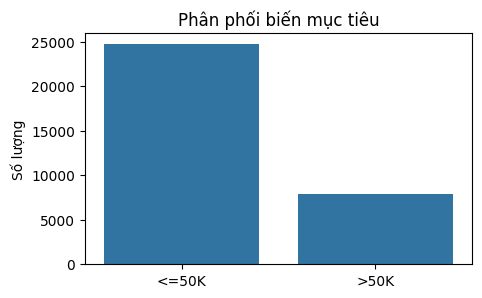

In [12]:
# Kiểu dữ liệu
print("Kiểu dữ liệu:")
display(df.dtypes.to_frame(name="dtype"))

# Thống kê mô tả
print("\nThống kê mô tả:")
display(df.describe(include="all").T)

# Phân phối biến mục tiêu
print("\nPhân phối biến mục tiêu:")
class_count = df[target_col].value_counts()
class_percent = df[target_col].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count': class_count,
    '%': class_percent.round(2)
})

display(summary)

# Plot
plt.figure(figsize=(5,3))
sns.countplot(x=target_col, data=df)
plt.title("Phân phối biến mục tiêu")
plt.xlabel("")
plt.ylabel("Số lượng")
plt.show()

**Nhận xét**  
- Dataset gồm **32561 dòng và 15 thuộc tính**, bao gồm cả biến số và biến phân loại.
  
- Một số thuộc tính có giá trị thiếu:
  - **occupation (~5.66%)**
  - **workclass (~5.64%)**
  - **native.country (~1.79%)**
  
  → Cần xử lý missing data cho các biến phân loại này trong bước tiền xử lý.

- Không có dòng hoàn toàn rỗng, dữ liệu tương đối sạch.

- Tập dữ liệu có 24 bản ghi trùng lặp (~0.07%). Do tỷ lệ không đáng kể, các bản ghi này được giữ lại vì không ảnh hưởng đáng kể đến kết quả phân tích.

- Về kiểu dữ liệu:
  - Các biến số đều có kiểu `int64`.
  - Các biến phân loại có kiểu `object`, phù hợp để thực hiện encoding sau này.
  → Không phát hiện sai lệch kiểu dữ liệu.

- Một số đặc điểm đáng chú ý:
  - **capital.gain** và **capital.loss** có trung vị bằng 0 và Q1 = Q3 = 0 → dữ liệu tập trung mạnh tại 0 (zero-inflated), có thể gây lệch phân phối.
  - **fnlwgt** có độ lệch chuẩn lớn (~105,550) → phân tán mạnh, có khả năng chứa ngoại lai.
  - **hours.per.week** tập trung quanh 40 giờ (median = 40, Q1 = 40) → phân phối không đều.
  - **education** và **education.num** biểu diễn cùng một thông tin → có thể gây dư thừa đặc trưng.

- Về biến mục tiêu:
  - <=50K chiếm **75.92%**
  - \>50K chiếm **24.08%**
  → Dataset có **mất cân bằng nhẹ**, nhưng chưa đến mức nghiêm trọng.

**Kết luận**  

Dataset nhìn chung có chất lượng tốt, tuy nhiên tồn tại một số vấn đề cần xử lý:
- Missing values
- Duplicate rows
- Các biến lệch phân phối
- Dư thừa đặc trưng

Những vấn đề này sẽ được xử lý trong các bước tiền xử lý tiếp theo.

# 2. EDA chuyên sâu
## 2.1 Kiểm định phân phối từng thuộc tính số

### Mục tiêu
Xác định liệu các thuộc tính số có tuân theo phân phối chuẩn (normal distribution) hay không. Kết quả này sẽ ảnh hưởng trực tiếp đến việc lựa chọn phương pháp chuẩn hóa (normalization) và các kiểm định thống kê tiếp theo.

---

### 2.1.1 Shapiro-Wilk Test (n ≤ 5000)

#### Giả thuyết:
- \\( H_0 \\): Dữ liệu tuân theo phân phối chuẩn
- \\( H_1 \\): Dữ liệu không tuân theo phân phối chuẩn

#### Công thức:

\\[
W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\\]

Trong đó:
- \\( x_{(i)} \\): giá trị đã được sắp xếp (order statistics)
- \\( a_i \\): hệ số được xác định dựa trên kỳ vọng và hiệp phương sai của phân phối chuẩn
- \\( \bar{x} \\): giá trị trung bình

#### Ý nghĩa:
- Giá trị \\( W \\) càng gần 1 → dữ liệu càng gần phân phối chuẩn

---

### 2.1.2 D’Agostino-Pearson Test (n > 5000)

#### Giả thuyết:
- \\( H_0 \\): Dữ liệu tuân theo phân phối chuẩn
- \\( H_1 \\): Dữ liệu không tuân theo phân phối chuẩn

#### Nguyên lý:
Kiểm tra đồng thời:
- **Skewness (độ lệch)**: đo độ bất đối xứng
- **Kurtosis (độ nhọn)**: đo độ tập trung

#### Công thức thống kê:

\\[
K^2 = Z_1^2 + Z_2^2
\\]

Trong đó:
- \\( Z_1 \\): z-score của skewness
- \\( Z_2 \\): z-score của kurtosis

#### Ý nghĩa:
- Nếu dữ liệu lệch hoặc nhọn bất thường → không phải phân phối chuẩn

---

### 2.1.3 Diễn giải kết quả

- \\( p \geq 0.05 \\):  
  → Chưa đủ bằng chứng để bác bỏ \\( H_0 \\)  
  → Dữ liệu có thể được xem là phân phối chuẩn

- \\( p < 0.05 \\):  
  → Bác bỏ \\( H_0 \\)  
  → Dữ liệu có xu hướng không tuân theo phân phối chuẩn
  
---

### 2.1.4 Ý nghĩa

- Nếu dữ liệu **chuẩn** → có thể dùng:
  - Z-score normalization
  - Các mô hình giả định Gaussian (LDA, Logistic Regression)

- Nếu dữ liệu **không chuẩn** → nên cân nhắc:
  - Robust Scaling
  - Quantile Transformation
  - Log transformation
  
---
  
### 2.1.5 Lưu ý

Với kích thước mẫu lớn, các kiểm định thống kê trở nên rất nhạy, dẫn đến p-value thường nhỏ.  
Do đó, cần kết hợp thêm các phương pháp trực quan như histogram hoặc KDE để đánh giá phân phối dữ liệu một cách toàn diện hơn.

In [13]:
normality_results = []

n_rows = len(df)
for col in numeric_cols:
    series = df[col].dropna()
    if len(series) <= 5000:
        stat, p = shapiro(series.sample(min(5000, len(series)), random_state=42))
        test_name = "Shapiro-Wilk"
    else:
        stat, p = normaltest(series)
        test_name = "D'Agostino-Pearson"
    normality_results.append({
        "feature": col,
        "test": test_name,
        "statistic": stat,
        "p_value": p,
        "distribution": "Normal-like" if p >= 0.05 else "Non-normal"
    })

normality_df = pd.DataFrame(normality_results).sort_values("p_value")
display(normality_df)

,feature,test,statistic,p_value,distribution
0,age,D'Agostino-Pearson,1526.010846,0.000000e+00,Non-normal
1,fnlwgt,D'Agostino-Pearson,10662.513695,0.000000e+00,Non-normal
3,capital.gain,D'Agostino-Pearson,55096.550375,0.000000e+00,Non-normal
4,capital.loss,D'Agostino-Pearson,29331.399856,0.000000e+00,Non-normal
5,hours.per.week,D'Agostino-Pearson,2508.918440,0.000000e+00,Non-normal
2,education.num,D'Agostino-Pearson,817.164145,3.589720e-178,Non-normal


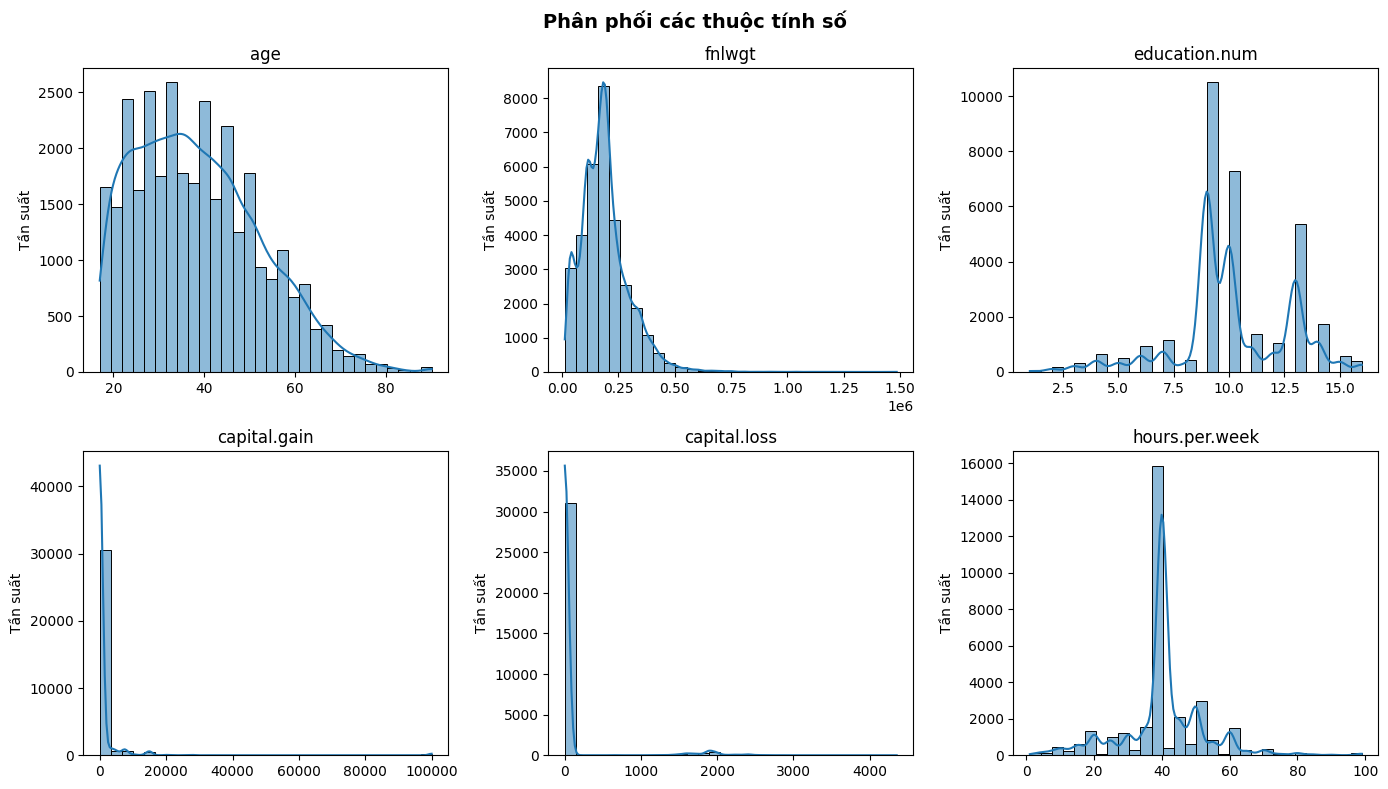

In [14]:
ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Tần suất")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle("Phân phối các thuộc tính số", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét**  

Kết quả kiểm định cho thấy tất cả các thuộc tính số đều có p-value < 0.05, do đó bác bỏ giả thuyết H₀. Điều này cho thấy dữ liệu không tuân theo phân phối chuẩn.

Quan sát từ biểu đồ:

- `fnlwgt` lệch phải mạnh, cho thấy tồn tại nhiều giá trị lớn bất thường  
- `capital.gain` và `capital.loss` tập trung chủ yếu tại 0, thể hiện đặc điểm zero-inflated  
- `hours.per.week` tập trung quanh 40, không tuân theo phân phối chuẩn  
- `age` có lệch nhẹ  
- `education.num` là biến rời rạc, không phù hợp với giả định Gaussian  

**Kết luận**  

Do dữ liệu không tuân theo phân phối chuẩn và có dấu hiệu lệch mạnh, việc sử dụng Z-score normalization (StandardScaler) có thể không tối ưu.

Thay vào đó, nên ưu tiên các phương pháp ít nhạy với ngoại lai như:

- RobustScaler để giảm ảnh hưởng của ngoại lai  
- QuantileTransformer để biến đổi phân phối dữ liệu  

Ngoài ra, với các biến lệch mạnh, có thể áp dụng thêm log transformation để giảm skewness.

## 2.2 Phân tích tương quan đa biến

Đánh giá mối quan hệ giữa các thuộc tính số nhằm phát hiện nguy cơ đa cộng tuyến.

---

### 2.2.1 Hệ số tương quan Pearson

Hệ số tương quan Pearson đo mức độ quan hệ tuyến tính giữa hai biến số:

\\[
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
\\]

- \\( r \in [-1, 1] \\)
- \\( r > 0 \\): tương quan thuận  
- \\( r < 0 \\): tương quan nghịch  
- \\( |r| \\) càng gần 1 → mối quan hệ càng mạnh  

---

### 2.2.2 Hệ số tương quan Spearman

Spearman đo mối quan hệ đơn điệu giữa hai biến dựa trên thứ hạng:

\\[
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
\\]

- \\( d_i \\): chênh lệch thứ hạng giữa hai biến  
- Ít nhạy với outlier và không yêu cầu phân phối chuẩn  

---

### 2.2.3 Đa cộng tuyến (Multicollinearity)

Đa cộng tuyến xảy ra khi các biến độc lập có tương quan mạnh với nhau, gây ra:

- Ước lượng hệ số không ổn định  
- Khó diễn giải mô hình  
- Giảm hiệu suất của các mô hình tuyến tính  

Thông thường:
- \\( |r| > 0.9 \\) → tương quan rất mạnh → có nguy cơ đa cộng tuyến  

---

### 2.2.4. Ý nghĩa

- Nếu tồn tại đa cộng tuyến:
  - Có thể loại bỏ một trong hai biến tương quan cao  
  - Hoặc sử dụng các phương pháp giảm chiều như PCA  

- Nếu không có đa cộng tuyến:
  - Có thể giữ lại toàn bộ biến cho mô hình

In [15]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

def find_high_corr_pairs(corr_df, threshold=0.9):
    pairs = []
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr_df.iloc[i, j]
            if abs(val) > threshold:
                pairs.append((cols[i], cols[j], val))
    return (
        pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"])
        .sort_values("corr", key=np.abs, ascending=False)
        .reset_index(drop=True)
    )

high_pearson = find_high_corr_pairs(pearson_corr, threshold=0.9)
high_spearman = find_high_corr_pairs(spearman_corr, threshold=0.9)

print("Các cặp tương quan Pearson cao (|r| > 0.9):")
display(high_pearson if len(high_pearson) else pd.DataFrame({"message": ["Không có cặp nào vượt ngưỡng"]}))

print("\nCác cặp tương quan Spearman cao (|r| > 0.9):")
display(high_spearman if len(high_spearman) else pd.DataFrame({"message": ["Không có cặp nào vượt ngưỡng"]}))

Các cặp tương quan Pearson cao (|r| > 0.9):


,message
0,Không có cặp nào vượt ngưỡng



Các cặp tương quan Spearman cao (|r| > 0.9):


,message
0,Không có cặp nào vượt ngưỡng


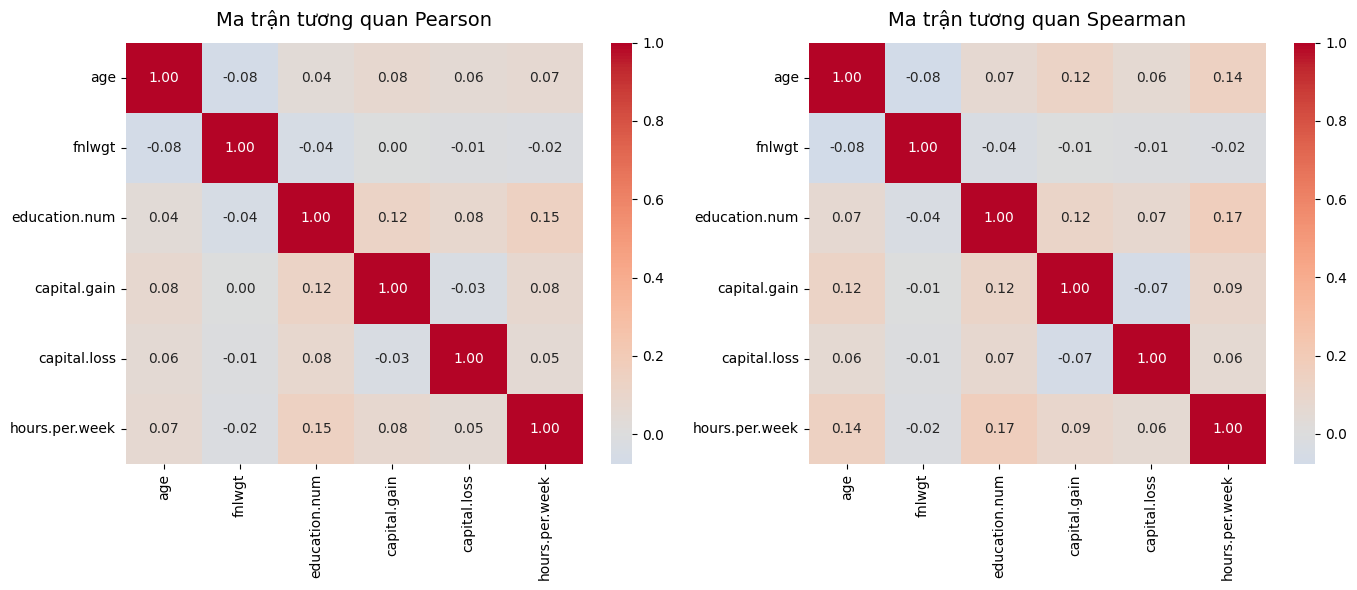

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Ma trận tương quan Pearson", fontsize=14, pad=12)

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Ma trận tương quan Spearman", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

**Nhận xét**

Kết quả từ ma trận tương quan Pearson và Spearman cho thấy các thuộc tính số có mức tương quan thấp.

- Không tồn tại cặp biến nào có hệ số tương quan lớn (|r| > 0.9), do đó không có dấu hiệu đa cộng tuyến mạnh.
- Các giá trị tương quan chủ yếu nằm trong khoảng [-0.3, 0.3], cho thấy mối quan hệ giữa các biến là yếu.

Một số mối quan hệ đáng chú ý:

- `education.num` có tương quan dương nhẹ với `hours.per.week` và `capital.gain`  
- `capital.gain` và `capital.loss` có tương quan âm nhẹ (Spearman ≈ -0.07), phản ánh xu hướng ngược chiều nhưng không mạnh  
- `fnlwgt` hầu như không tương quan với các biến khác  

Kết quả giữa Pearson và Spearman tương đối nhất quán, cho thấy các mối quan hệ giữa các biến không phụ thuộc mạnh vào dạng phân phối.

## 2.3 Phân tích giá trị thiếu

Các giá trị thiếu tập trung chủ yếu ở một số biến và cần được phân tích để xác định cơ chế thiếu dữ liệu cũng như phương pháp xử lý phù hợp.

Có 3 cơ chế thiếu dữ liệu chính:

- **MCAR (Missing Completely At Random):** giá trị thiếu xảy ra hoàn toàn ngẫu nhiên  
- **MAR (Missing At Random):** giá trị thiếu phụ thuộc vào các biến quan sát khác  
- **MNAR (Missing Not At Random):** giá trị thiếu phụ thuộc vào chính giá trị bị thiếu  
  
**Little’s MCAR test** thường được sử dụng để kiểm tra dữ liệu có thiếu hoàn toàn ngẫu nhiên hay không, với giả thuyết:
- \\( H_0 \\): dữ liệu thiếu theo cơ chế MCAR  
- \\( H_1 \\): dữ liệu không phải MCAR  

In [17]:
display(missing_df)

,missing_count,missing_ratio (%)
occupation,1843,5.66
workclass,1836,5.64
native.country,583,1.79
age,0,0.00
fnlwgt,0,0.00
education,0,0.00
education.num,0,0.00
marital.status,0,0.00
relationship,0,0.00
race,0,0.00


Trong tập dữ liệu này, các giá trị thiếu chủ yếu xuất hiện ở các biến phân loại như `workclass`, `occupation` và `native.country`.   
Do đó, việc áp dụng Little’s MCAR test không thực sự phù hợp: 
- Nếu chỉ sử dụng các biến số → kiểm định không phản ánh đúng phần dữ liệu bị thiếu
- Nếu mã hóa các biến phân loại sang dạng số (ví dụ Label Encoding) → tạo quan hệ số học giả và vi phạm giả định thống kê của kiểm định

Vì vậy, nhóm không sử dụng Little’s MCAR test như bằng chứng chính, mà thay vào đó áp dụng các phương pháp phân tích trực quan và định tính.

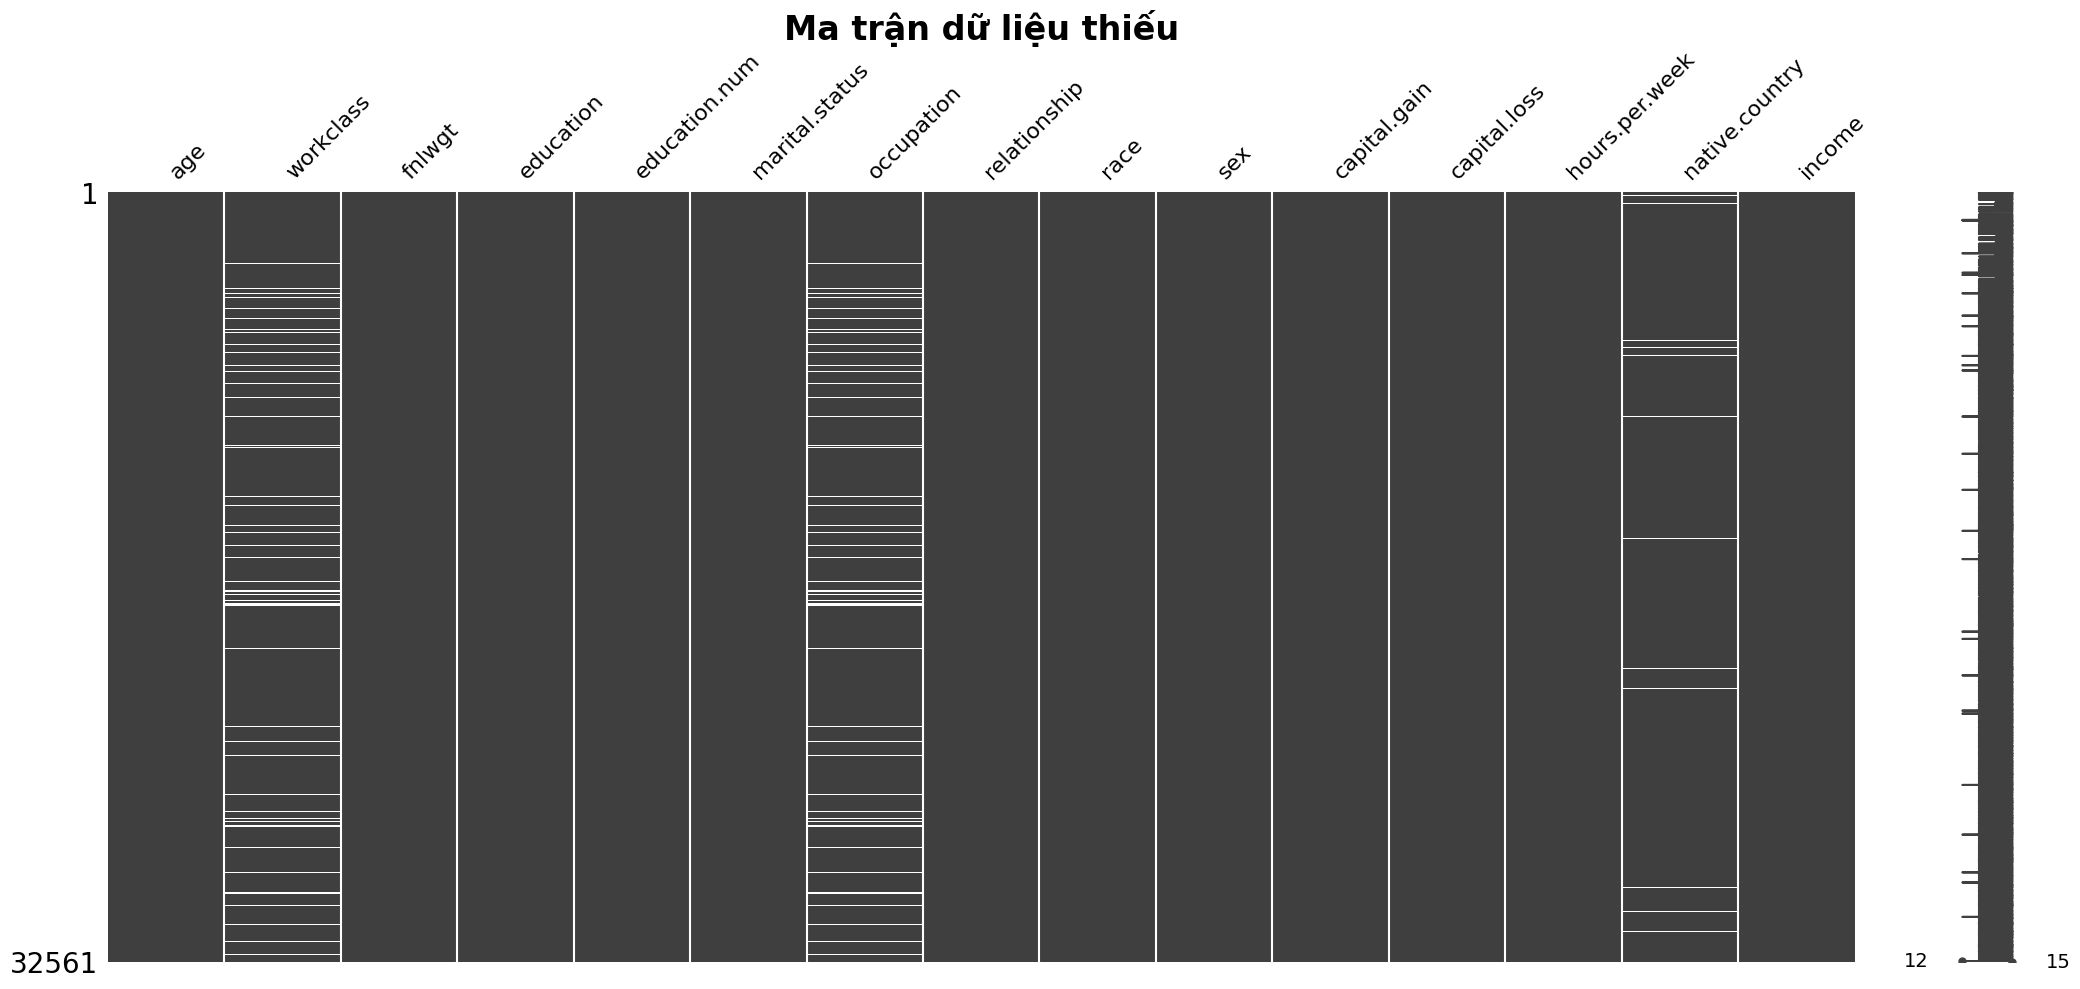

In [18]:
msno.matrix(df)
plt.title("Ma trận dữ liệu thiếu", fontsize=24, fontweight='bold')
plt.show()

**Nhận xét**  

Biểu đồ cho thấy giá trị thiếu tập trung ở một số biến nhất định và không phân bố ngẫu nhiên hoàn toàn trong toàn bộ dataset.

Đáng chú ý, `workclass` và `occupation` thường thiếu đồng thời trên cùng một quan sát, trong khi các biến còn lại gần như đầy đủ. Điều này cho thấy việc thiếu dữ liệu không xảy ra ngẫu nhiên hoàn toàn.

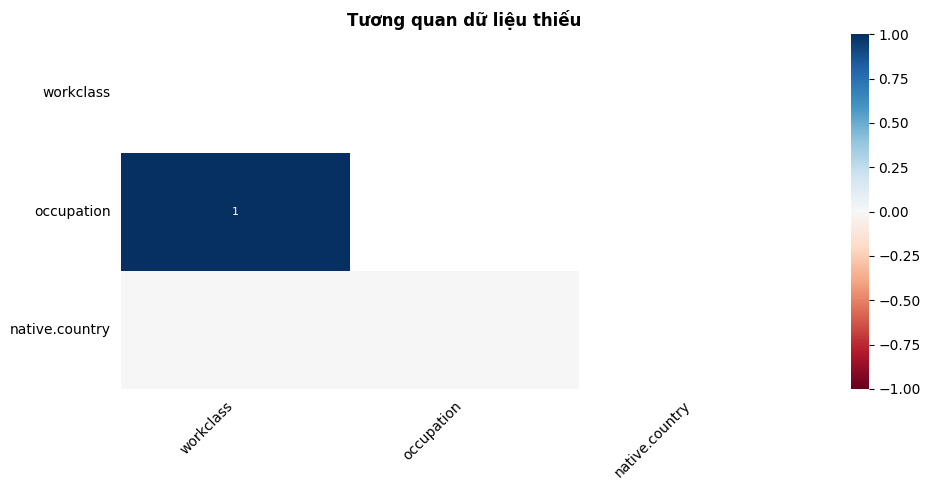

In [19]:
msno.heatmap(df, figsize=(10, 5), fontsize=10)
plt.title("Tương quan dữ liệu thiếu", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét**  
Kết quả cho thấy các biến như `workclass` và `occupation` có tương quan thiếu cao, cho thấy hiện tượng đồng thiếu (co-missing) rõ rệt giữa các biến này. Điều này cho thấy việc thiếu dữ liệu không xảy ra độc lập giữa các biến.

### Kiểm định Chi-square với biến chỉ báo thiếu
Để kiểm tra mối quan hệ giữa hiện tượng thiếu và các biến quan sát khác, nhóm sử dụng kiểm định Chi-square trên biến chỉ báo thiếu (missing indicator).  

In [20]:
# Các biến phân loại có missing cần kiểm tra
missing_targets = ['workclass', 'occupation', 'native.country']

results = []

for target in missing_targets:
    print(f"\n===== Kiểm tra missing của {target} =====")
    
    target_missing = df[target].isna().astype(int)
    
    for col in missing_targets:
        if col == target:
            continue
        
        # Chỉ giữ các dòng mà biến giải thích không bị thiếu
        temp = df[[col]].copy()
        temp["target_missing"] = target_missing
        temp = temp[temp[col].notna()]
        
        contingency = pd.crosstab(temp["target_missing"], temp[col])
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        dependent = p < 0.05
        
        print(f"Test với {col}: p-value = {p:.4f}")
        if dependent:
            print("→ Có phụ thuộc → không MCAR")
        else:
            print("→ Không đủ bằng chứng")
        
        results.append({
            "target_missing": target,
            "tested_against": col,
            "p_value": p,
            "dependent": "Yes" if dependent else "No"
        })

# Bảng tổng hợp
dependency_df = pd.DataFrame(results)
print("\nBảng tổng hợp:")
display(dependency_df)


===== Kiểm tra missing của workclass =====
Test với occupation: p-value = 1.0000
→ Không đủ bằng chứng
Test với native.country: p-value = 0.1112
→ Không đủ bằng chứng

===== Kiểm tra missing của occupation =====
Test với workclass: p-value = 0.0000
→ Có phụ thuộc → không MCAR
Test với native.country: p-value = 0.1131
→ Không đủ bằng chứng

===== Kiểm tra missing của native.country =====
Test với workclass: p-value = 0.0001
→ Có phụ thuộc → không MCAR
Test với occupation: p-value = 0.0000
→ Có phụ thuộc → không MCAR

Bảng tổng hợp:


,target_missing,tested_against,p_value,dependent
0,workclass,occupation,1.000000,No
1,workclass,native.country,0.111239,No
2,occupation,workclass,0.000000,Yes
3,occupation,native.country,0.113110,No
4,native.country,workclass,0.000123,Yes
5,native.country,occupation,0.000026,Yes


### Kết luận
Từ các phân tích trên:
- Giá trị thiếu tập trung ở một số biến phân loại
- Có hiện tượng đồng thiếu giữa các biến
- Có bằng chứng thống kê cho thấy hiện tượng thiếu phụ thuộc vào biến quan sát khác

Do đó, dữ liệu không phù hợp với giả định MCAR, mà hợp lý hơn với cơ chế **MAR (Missing At Random)**, khi việc thiếu giá trị có liên quan đến các đặc trưng khác trong dataset.